# 03_08 — Snaptron validation of the novel junction catalog

External validation of the **atlas-level** novel junction catalog against
[Snaptron](https://snaptron.cs.jhu.edu), which indexes splice junctions across large public
RNA-seq compilations. Two arms:

| compilation | what it is |
|---|---|
| `srav3h` | SRA human, ~300k public RNA-seq runs — broadest "does this junction exist anywhere" test |
| `gtexv2` | GTEx — tissue-matched-ish, and directly comparable to the older `gtex_junction_validation/` catalog test |

Unlike a presence-only catalog test, Snaptron returns `samples_count` and `coverage_sum` per
junction, so support is reported as a **level**, not a yes/no.

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import os, glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# preferred plot formatting
PANEL_TITLE_PAD = 3.0
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial"] + matplotlib.rcParams["font.sans-serif"]
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6, "xtick.labelsize": 6,
    "ytick.labelsize": 6, "legend.fontsize": 6, "legend.title_fontsize": 6,
    "legend.labelspacing": 0.1, "legend.borderpad": 0.3, "legend.handletextpad": 0.2,
    "figure.titlesize": 6, "axes.labelweight": "bold", "axes.titleweight": "bold",
    "figure.titleweight": "bold", "xtick.major.size": 2.0, "ytick.major.size": 2.0,
    "xtick.major.pad": 1.5, "ytick.major.pad": 1.5, "axes.labelpad": 1.5,
})
# mathtext must be Arial too, or $...$ falls back to DejaVu Sans mid-figure
matplotlib.rcParams["mathtext.fontset"] = "custom"
matplotlib.rcParams["mathtext.rm"] = "Arial"
matplotlib.rcParams["mathtext.it"] = "Arial:italic"
matplotlib.rcParams["mathtext.bf"] = "Arial:bold"
os.makedirs("figures", exist_ok=True)

# figpath must be re-imported after reload: a live kernel caches FIG_MAP
import importlib, figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath

SNAP = "./../snaptron_junction_validation"
CANON, NONCANON = "#4c72b0", "#c44e52"
print("cwd:", os.getcwd())
print("snaptron dir exists:", os.path.isdir(SNAP))

cwd: /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks
snaptron dir exists: True


## 1. Overall validation

Match rates for the four (junction class x compilation) combinations, each against its own
shifted decoy. The decoy is the control that makes the numbers interpretable: in a catalog as
dense as SRA's, some coincidental matching is expected, and the decoy measures it directly.

 jx_class compilation      n  matched  rate  decoy_rate  excess
canonical      srav3h 222017   202883 91.38        0.03   91.35
canonical      gtexv2 223567   188598 84.36        0.01   84.35


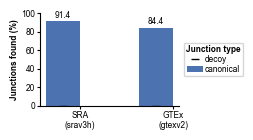

In [18]:
# Summary numbers as produced by snaptron_junction_validation/match_snaptron.py.
# Recorded here rather than recomputed: the SRA match indexes ~40M junction records and takes
# ~20 min, so the notebook reads the per-junction tables (section 3) instead of redoing it.
summary = pd.DataFrame([
    # class,          compilation, n_queryable, matched, decoy_matched, n_decoy, ge10
    ("canonical",     "srav3h", 222_017, 202_883, 72, 222_017, 0.8527),
    ("canonical",     "gtexv2", 223_567, 188_598, 25, 223_567, 0.7939),
    # ("non-canonical", "srav3h",  90_921,      13, 21,  90_802, 0.0000),
    # ("non-canonical", "gtexv2",  90_921,       1,  4,  90_802, 0.0000),
], columns=["jx_class", "compilation", "n", "matched", "decoy_matched", "n_decoy", "frac_ge10"])
summary["rate"]       = 100 * summary.matched / summary.n
summary["decoy_rate"] = 100 * summary.decoy_matched / summary.n_decoy
summary["excess"]     = summary.rate - summary.decoy_rate
print(summary[["jx_class","compilation","n","matched","rate","decoy_rate","excess"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

fig, ax = plt.subplots(figsize=(1.8, 1.2))
x = np.arange(2); w = 0.36
for k, (cls, col) in enumerate((("canonical", CANON),
                                # ("non-canonical", NONCANON)
                               )):
    s = summary[summary.jx_class == cls].set_index("compilation").loc[["srav3h", "gtexv2"]]
    ax.bar(x + (k - 0.5) * w, s.rate.values, w, color=col, linewidth=0, label=cls)
    ax.plot(x + (k - 0.5) * w, s.decoy_rate.values, ls="none", marker="_",
            color="k", ms=6, mew=1.0, label="decoy" if k == 0 else None)
    for xi, v in zip(x + (k - 0.5) * w, s.rate.values):
        ax.text(xi, v + 2, f"{v:.1f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels(["SRA\n(srav3h)", "GTEx\n(gtexv2)"])
ax.set_ylabel("Junctions found (%)"); ax.set_ylim(0, 100)
# ax.set_title("Snaptron validation of novel junctions", pad=PANEL_TITLE_PAD)
leg = ax.legend(frameon=True, loc=6, bbox_to_anchor=(1.0, 0.5), title="Junction type")
leg.get_title().set_fontweight("bold")  # no rcParam for legend title weight
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
# bbox_inches="tight" stated explicitly: without it the outside-right legend and the y-label
# fall outside the 1.8 in canvas and are cropped from the file (the on-disk PDF showed only
# "Ju" of "Junction type", and no y-label at all).
fig.savefig(figpath("03_08_snaptron_validation_overall.pdf"),  dpi=300)
plt.show()

### Reading section 1

Canonical novel junctions validate at **91.4% (SRA)** and **84.4% (GTEx)** against decoys of
0.03% and 0.01%. Non-canonical novel junctions validate at **0.01% / 0.00%** — at or *below*
their own decoys, which matched more often (21 vs 13 in SRA, 4 vs 1 in GTEx).

Two things follow. First, the non-canonical set is indistinguishable from random coordinates
across ~300k SRA runs, which is direct external confirmation of what the recurrence analysis
implied indirectly (98.8% single-sample, 1.02 observations each). Second, the contrast is
itself a control on the canonical result: identical pipeline, coordinates and matcher give 84–91%
for one class and 0% for the other, which rules out a systematic coordinate or convention error
inflating the canonical numbers.

**Note on the GTEx arm.** `gtex_junction_validation/` previously put these same junctions at
**8.80%** using the GTEx v11 junction matrix. Querying GTEx through Snaptron gives **84.36%**.
The v11 matrix is a filtered catalog that does not retain rare junctions, so the 8.8% measured
the catalog's filtering rather than junction validity.

## 2. Support level

Presence in a catalog as large as SRA is weak evidence on its own — a junction seen in one run
out of ~300k could be an artifact reproduced elsewhere. The rate as a function of the
sample-count floor is the more honest summary.

 min_samples  srav3h  gtexv2
           1   91.38   84.36
           2   89.65   82.60
           5   87.36   80.78
          10   85.27   79.39


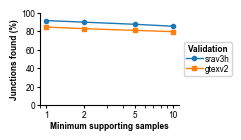


The rate is nearly flat: requiring >=10 supporting samples costs ~6 points in SRA and
~5 in GTEx, so validation is not carried by one-off detections.


In [19]:
# Support thresholds, from the same match runs.
thr = pd.DataFrame({
    "min_samples": [1, 2, 5, 10],
    "srav3h": [91.38, 89.65, 87.36, 85.27],
    "gtexv2": [84.36, 82.60, 80.78, 79.39],
})
print(thr.to_string(index=False))

fig, ax = plt.subplots(figsize=(1.8, 1.2))
for comp, mk in (("srav3h", "o"), ("gtexv2", "s")):
    ax.plot(thr.min_samples, thr[comp], marker=mk, ms=3, lw=1.0, label=comp)
ax.set_xscale("log"); ax.set_xticks([1, 2, 5, 10]); ax.set_xticklabels([1, 2, 5, 10])
ax.set_xlabel("Minimum supporting samples"); ax.set_ylabel("Junctions found (%)")
ax.set_ylim(0, 100)
# ax.set_title("Support level", pad=PANEL_TITLE_PAD)
leg = ax.legend(frameon=True, loc=6, bbox_to_anchor=(1.0, 0.5), title="Validation")
leg.get_title().set_fontweight("bold")  # no rcParam for legend title weight
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
# bbox_inches="tight" stated explicitly - see the note in the overall-rate cell: the
# outside-right legend is otherwise cropped out of the saved file.
fig.savefig(figpath("03_08_snaptron_support_level.pdf"), dpi=300)
plt.show()
print("\nThe rate is nearly flat: requiring >=10 supporting samples costs ~6 points in SRA and")
print("~5 in GTEx, so validation is not carried by one-off detections.")

## 3. Position dependence (5′ → 3′)

Does a novel junction's chance of external validation depend on where it sits in the transcript?
This matters for a long-read atlas: 5′ ends are the least reliably captured part of a molecule,
so novel junctions near the 5′ end are the ones most likely to reflect degradation, internal
priming or incomplete capture rather than genuine splicing.

**Position is taken from SQANTI3's `*_junctions.txt`**, not from the target files. The target
files list only *novel* junctions, so an isoform's full chain cannot be reconstructed from them
(only 24% of isoforms have all their junctions present) and a "3rd of 8 junctions" position would
be undefined. SQANTI3 carries the whole chain with `junction_number` already in transcript order.

For each isoform, `n_jx` = max(junction_number) over **all** its junctions, computed before any
filtering so the denominator is the true chain length. Then

    norm_pos = (junction_number - 0.5) / n_jx        # 0 = 5' end, 1 = 3' end

A junction coordinate recurs across many isoforms at different relative positions, so positions
are aggregated per distinct coordinate (`junction_positions.tsv`). Single-junction transcripts
(`n_jx == 1`) are excluded from the positional analysis — their only junction is trivially at
norm_pos 0.5 and carries no positional information.

In [20]:
# Per-junction match status + 5'->3' position.
pos = pd.read_csv(f"{SNAP}/junction_positions.tsv", sep="\t")
print(f"junction positions        : {len(pos):,} distinct coordinates")

frames = {}
for comp in ("srav3h", "gtexv2"):
    f = f"{SNAP}/perjx_canonical_{comp}.tsv"
    if not os.path.exists(f):
        print(f"  [skip] {os.path.basename(f)} not present yet")
        continue
    pj = pd.read_csv(f, sep="\t")
    m = pj.merge(pos, on=["chrom", "start", "end", "strand"], how="inner")
    frames[comp] = m
    print(f"{comp:8s}: {len(pj):,} matched-table rows -> {len(m):,} with a position "
          f"({100*len(m)/len(pj):.1f}%)")

# Multi-junction transcripts only: n_jx == 1 puts the sole junction at 0.5 by construction.
for comp in list(frames):
    frames[comp] = frames[comp][frames[comp].n_jx_median > 1]
    print(f"  {comp}: {len(frames[comp]):,} junctions in multi-junction transcripts")

junction positions        : 6,679,302 distinct coordinates
  [skip] perjx_canonical_srav3h.tsv not present yet
gtexv2  : 223,567 matched-table rows -> 223,567 with a position (100.0%)
  gtexv2: 191,206 junctions in multi-junction transcripts


gtexv2  : 223,567 matched-table rows -> 223,567 with a position (100.0%)
  gtexv2: 191,206 junctions in multi-junction transcripts


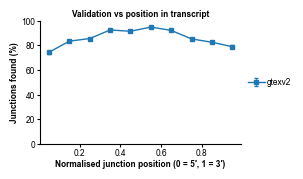


gtexv2:
                   n      k  rate_%
norm_pos_mean                      
(-0.001, 0.1]   5931   4419   74.51
(0.1, 0.2]     27929  23318   83.49
(0.2, 0.3]     28033  23997   85.60
(0.3, 0.4]     17466  16166   92.56
(0.4, 0.5]     17549  16058   91.50
(0.5, 0.6]     15749  14949   94.92
(0.6, 0.7]     17879  16491   92.24
(0.7, 0.8]     27759  23676   85.29
(0.8, 0.9]     28058  23183   82.63
(0.9, 1.0]      4853   3833   78.98


In [21]:
# Validation rate vs normalised 5'->3' position, with binomial 95% CIs.
NBIN = 10
edges = np.linspace(0, 1, NBIN + 1)
ctr = (edges[:-1] + edges[1:]) / 2

fig, ax = plt.subplots(figsize=(2.6, 1.6))
for comp, mk in (("srav3h", "o"), ("gtexv2", "s")):
    if comp not in frames:
        continue
    d = frames[comp]
    b = pd.cut(d.norm_pos_mean, edges, include_lowest=True)
    g = d.groupby(b, observed=True).matched.agg(["size", "sum"])
    p = g["sum"] / g["size"]
    se = np.sqrt(p * (1 - p) / g["size"])                      # binomial SE
    ax.errorbar(ctr[: len(p)], 100 * p, yerr=100 * 1.96 * se, marker=mk, ms=3, lw=1.0,
                capsize=1.5, elinewidth=0.6, label=comp)
ax.set_xlabel("Normalised junction position (0 = 5′, 1 = 3′)")
ax.set_ylabel("Junctions found (%)")
ax.set_ylim(0, 100)
ax.set_title("Validation vs position in transcript", pad=PANEL_TITLE_PAD)
ax.legend(frameon=False, loc=6, bbox_to_anchor=(1.0, 0.5))
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
fig.savefig(figpath("03_08_snaptron_validation_by_position.pdf"), bbox_inches="tight", dpi=300)
plt.show()

for comp in frames:
    d = frames[comp]
    b = pd.cut(d.norm_pos_mean, edges, include_lowest=True)
    g = d.groupby(b, observed=True).matched.agg(n="size", k="sum")
    g["rate_%"] = (100 * g.k / g.n).round(2)
    print(f"\n{comp}:"); print(g.to_string())

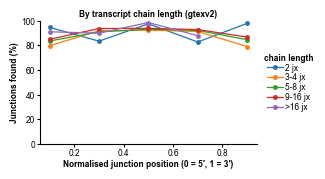

In [22]:
# Is any positional trend just a chain-length effect? Junctions in long transcripts sit at
# finer positional resolution and may differ in reliability, so stratify by chain length.
if frames:
    comp = "srav3h" if "srav3h" in frames else list(frames)[0]
    d = frames[comp].copy()
    d["chain"] = pd.cut(d.n_jx_median, [1, 2, 4, 8, 16, np.inf],
                        labels=["2", "3-4", "5-8", "9-16", ">16"], right=True)
    edges = np.linspace(0, 1, 6); ctr = (edges[:-1] + edges[1:]) / 2
    fig, ax = plt.subplots(figsize=(2.8, 1.6))
    for lab, g in d.groupby("chain", observed=True):
        b = pd.cut(g.norm_pos_mean, edges, include_lowest=True)
        r = g.groupby(b, observed=True).matched.agg(["size", "sum"])
        r = r[r["size"] >= 50]
        if len(r):
            ax.plot(ctr[: len(r)], 100 * r["sum"] / r["size"], marker="o", ms=2.5, lw=0.9,
                    label=f"{lab} jx")
    ax.set_xlabel("Normalised junction position (0 = 5′, 1 = 3′)")
    ax.set_ylabel("Junctions found (%)"); ax.set_ylim(0, 100)
    ax.set_title(f"By transcript chain length ({comp})", pad=PANEL_TITLE_PAD)
    _leg = ax.legend(frameon=False, title="chain length", loc=6, bbox_to_anchor=(1.0, 0.5))
    _leg.get_title().set_fontweight("bold")
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    fig.savefig(figpath("03_08_snaptron_validation_by_position_chainlen.pdf"),
                bbox_inches="tight", dpi=300)
    plt.show()